In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import allantools as at

In [25]:
files = ('data/influx/Influx_TEC4_21-05-26.csv',
         'data/influx/Influx_TEC4_24-06-26.csv')

df_1 = pd.read_csv(files[0], header=0)
df = pd.read_csv(files[1], header=0)

print(df['time'].iloc[0], df['time'].iloc[-1])

2026-06-24 13:58:00.227852+02:00 2026-06-24 14:57:59.822400+02:00


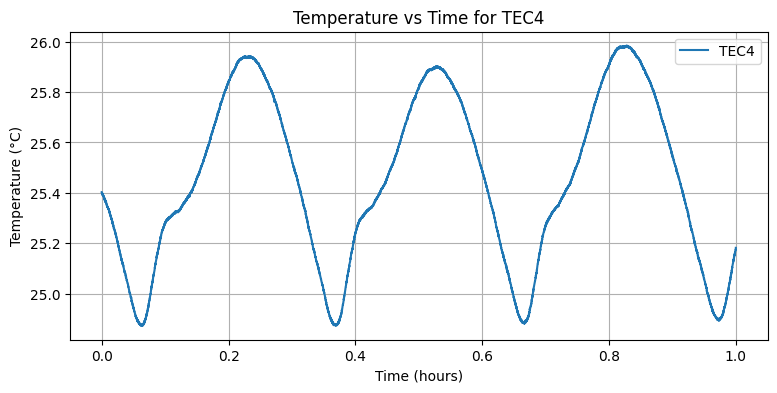

In [27]:
plt.figure(figsize=(9, 4))
plt.plot(df['time [s]'] / (60**2), df['value'], label='TEC4')

plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Time for TEC4')
plt.legend()
plt.grid()
plt.show()

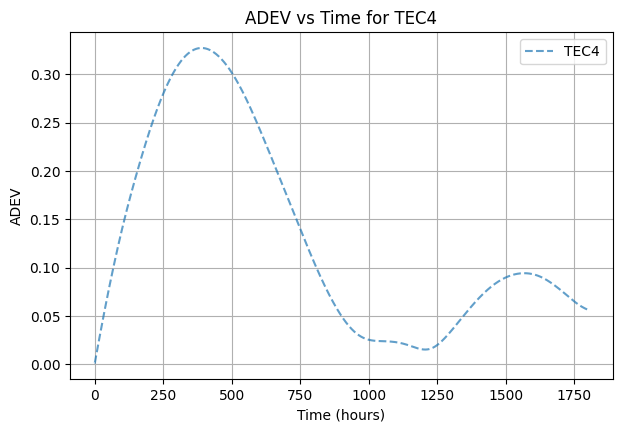

In [24]:
tau, adev, err, n = at.oadev(data=df['value'], rate=1/(np.mean(np.diff(df['time [s]']))), taus='all', data_type='freq')

plt.figure(figsize=(7, 4.5))
plt.errorbar(tau, adev, label='TEC4', alpha=0.7, fmt="--")
plt.xlabel('Time (hours)')
plt.ylabel('ADEV')
plt.title('ADEV vs Time for TEC4')
plt.legend()
plt.grid()
plt.show()